   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 888.1/888.1 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 115.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.2/287.2 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3

100%|██████████| 94.3M/94.3M [00:00<00:00, 202MB/s]


[INFO] EuroSAT downloaded to: /content/data  | Images: 27000 | Classes: 10


,class_id,class_name,count
0,0,AnnualCrop,3000
1,1,Forest,3000
2,2,HerbaceousVegetation,3000
3,3,Highway,2500
4,4,Industrial,2500
5,5,Pasture,2000
6,6,PermanentCrop,2500
7,7,Residential,3000
8,8,River,2500
9,9,SeaLake,3000


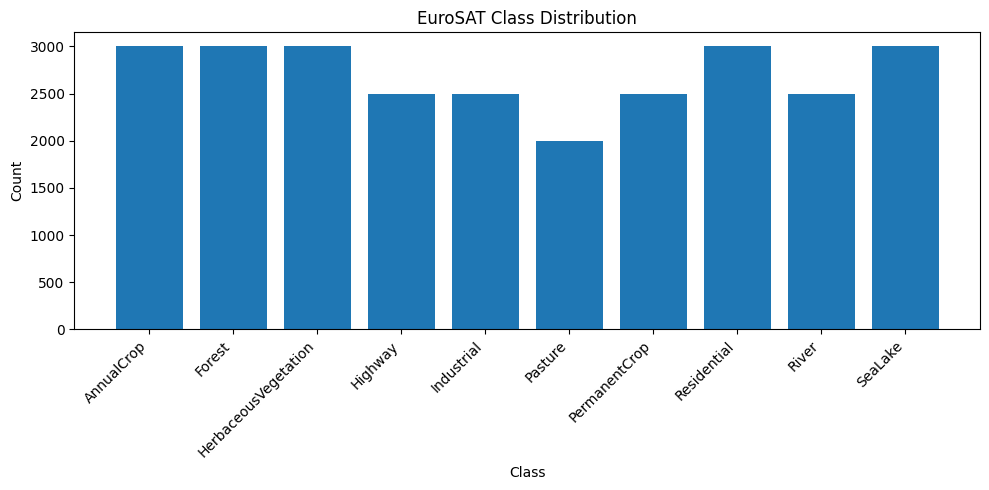

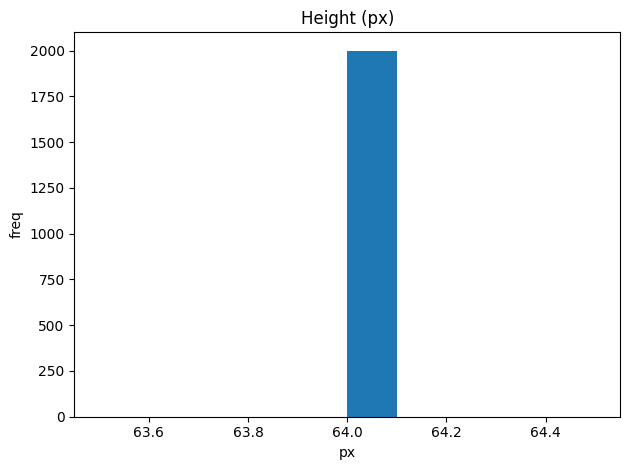

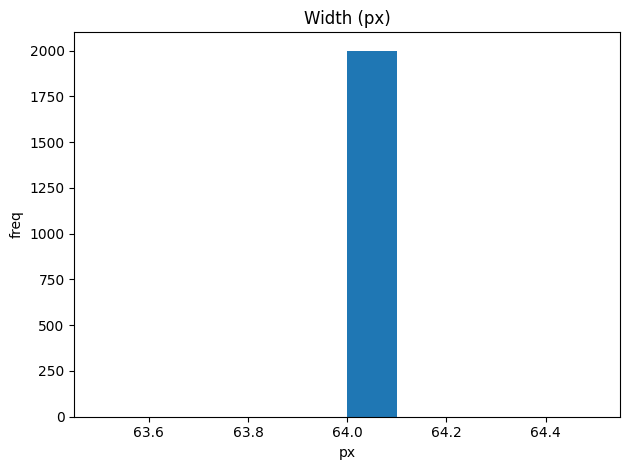

,channel,mean,std
0,R,0.344376,0.202661
1,G,0.380291,0.136897
2,B,0.407770,0.115550


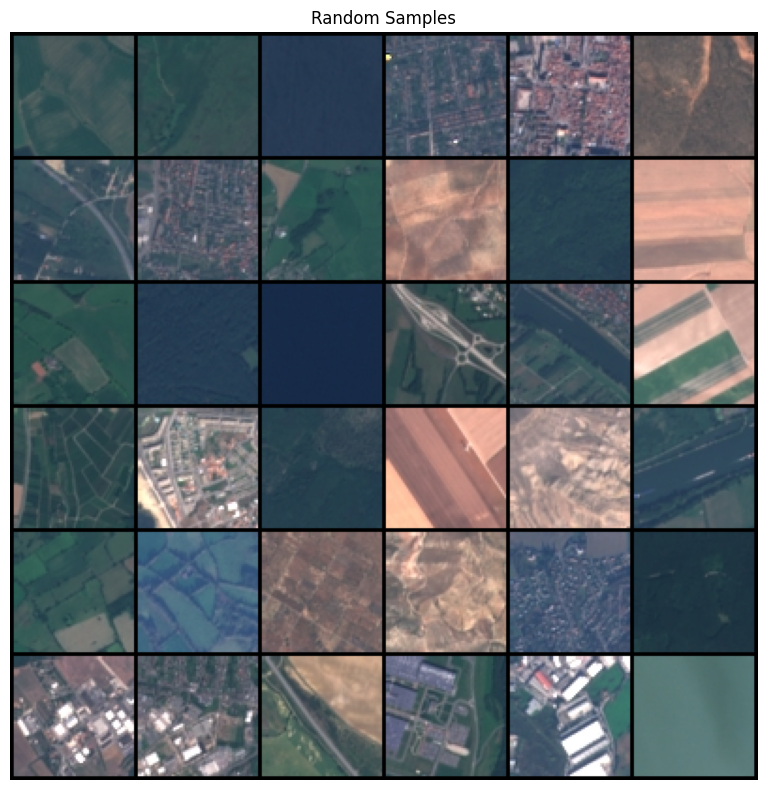

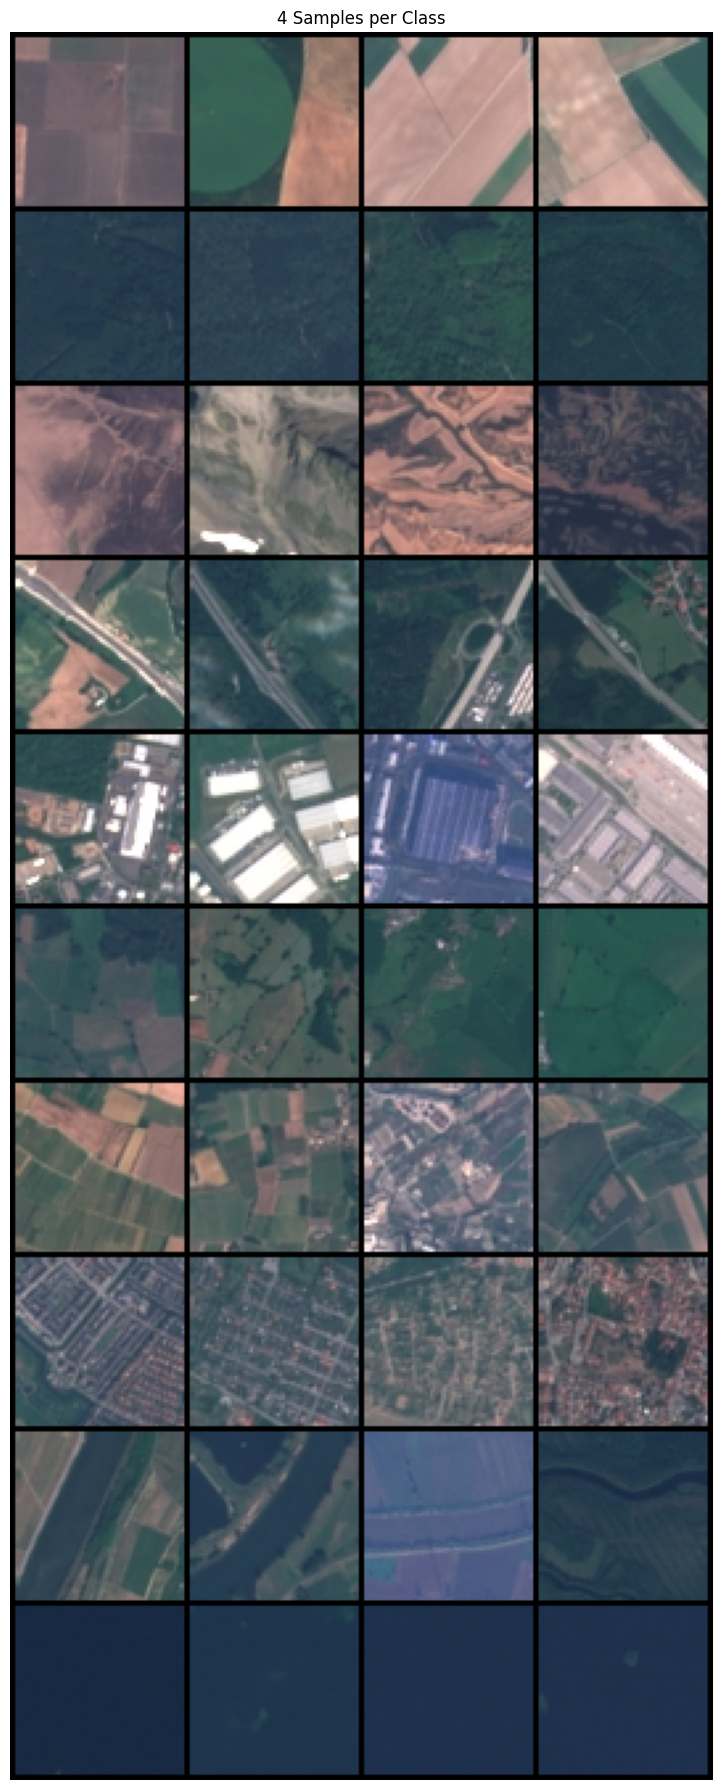

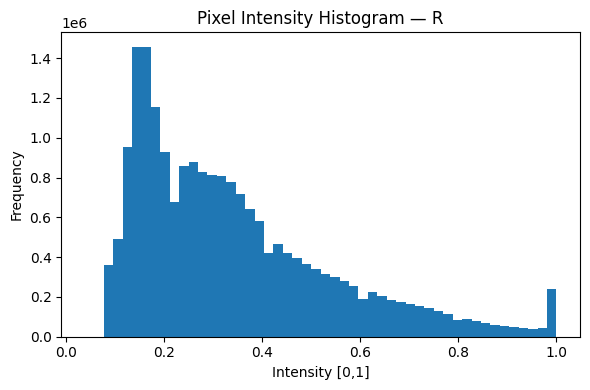

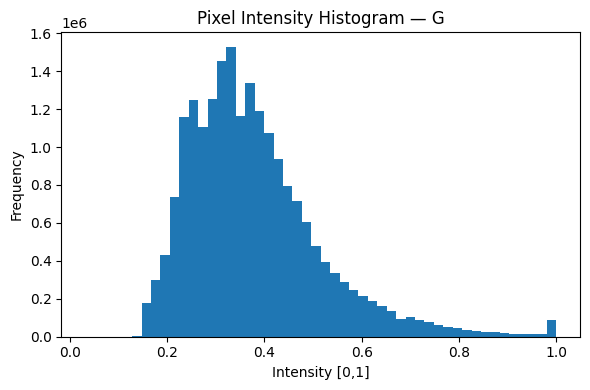

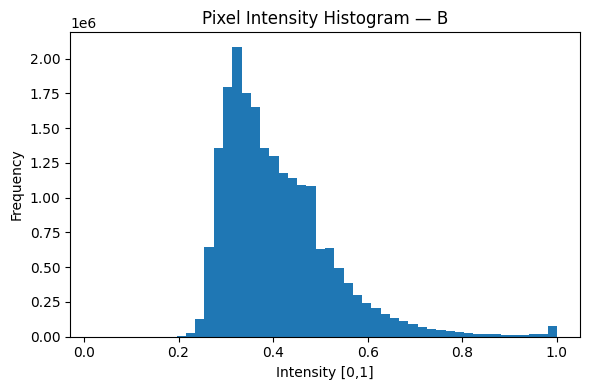

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 120MB/s]


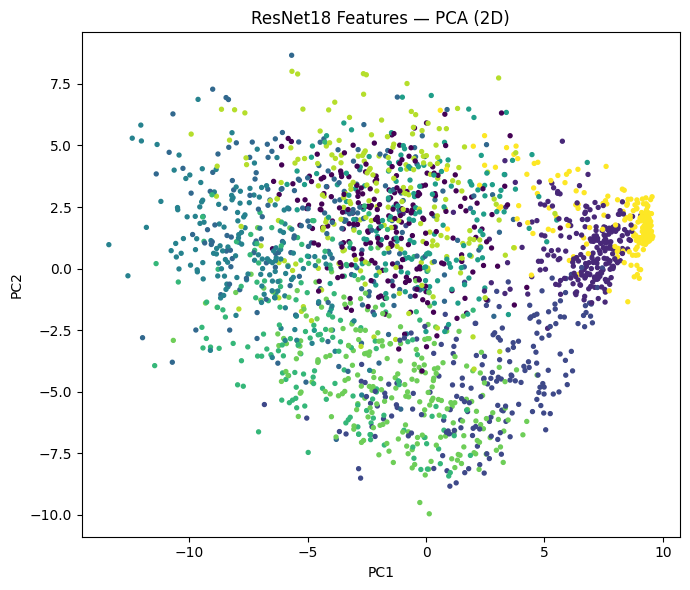

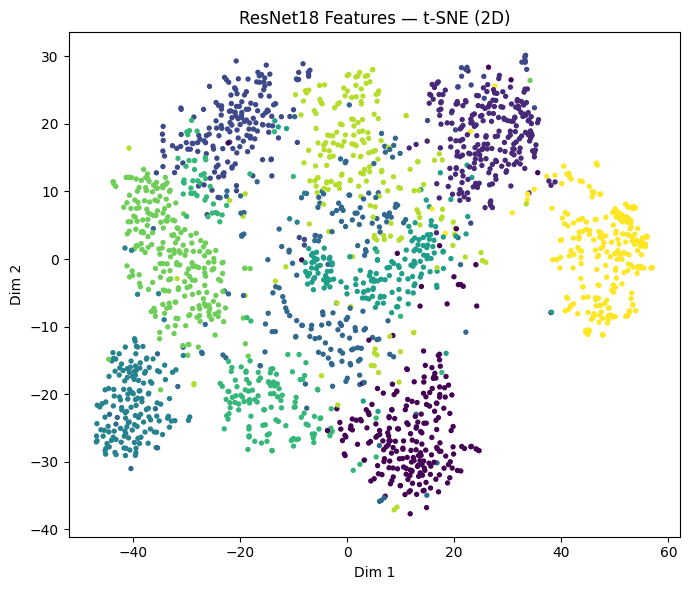


[DONE] Outputs saved in: /content/eda_out
total 2060
drwxr-xr-x 2 root root   4096 Aug 11 16:36 .
drwxr-xr-x 1 root root   4096 Aug 11 16:31 ..
-rw-r--r-- 1 root root    141 Aug 11 16:32 channel_stats.csv
-rw-r--r-- 1 root root    202 Aug 11 16:31 class_counts.csv
-rw-r--r-- 1 root root  95292 Aug 11 16:31 class_distribution.png
-rw-r--r-- 1 root root  35180 Aug 11 16:31 height_hist.png
-rw-r--r-- 1 root root  42439 Aug 11 16:32 hist_B.png
-rw-r--r-- 1 root root  38814 Aug 11 16:32 hist_G.png
-rw-r--r-- 1 root root  37662 Aug 11 16:32 hist_R.png
-rw-r--r-- 1 root root     18 Aug 11 16:31 image_sizes_counts.csv
-rw-r--r-- 1 root root 386654 Aug 11 16:36 pca_2d.png
-rw-r--r-- 1 root root 572172 Aug 11 16:32 per_class_grid.png
-rw-r--r-- 1 root root     63 Aug 11 16:32 pixel_range_sampled.csv
-rw-r--r-- 1 root root 425962 Aug 11 16:32 random_grid.png
-rw-r--r-- 1 root root   1421 Aug 11 16:36 summary_counts_and_channel_stats.csv
-rw-r--r-- 1 root root 386989 Aug 11 16:36 tsne_2d.png
-rw-

In [4]:
# CONFIG
MODE = "download"  
DATA_DIR = "/content/drive/MyDrive/EuroSAT"
OUT_DIR = "eda_out"
SEED = 42

!pip -q install torch torchvision --upgrade
import os, random, math
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, utils, models
from torchvision.datasets.folder import default_loader

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
os.makedirs(OUT_DIR, exist_ok=True)

# DATA LOADING
if MODE.lower() == "download":
    DATA_ROOT = "/content/data"
    ds_eurosat = datasets.EuroSAT(root=DATA_ROOT, download=True, transform=transforms.ToTensor())
    ds = ds_eurosat
    class_names = ds.classes
    num_classes = len(class_names)
    print(f"[INFO] EuroSAT downloaded to: {DATA_ROOT}  | Images: {len(ds)} | Classes: {num_classes}")

elif MODE.lower() == "drive":
    from google.colab import drive
    drive.mount('/content/drive')
    assert os.path.isdir(DATA_DIR), f"[ERROR] DATA_DIR not found: {DATA_DIR}"
    print("[INFO] Listing classes at:", DATA_DIR)
    !ls -la "$DATA_DIR" | head -n 50

    to_tensor = transforms.ToTensor()
    ds = datasets.ImageFolder(root=DATA_DIR, transform=to_tensor)
    class_names = ds.classes
    num_classes = len(class_names)
    print(f"[INFO] Loaded from Drive | Images: {len(ds)} | Classes: {num_classes} -> {class_names}")
else:
    raise ValueError("MODE must be 'download' or 'drive'.")

# Class Distribution

if hasattr(ds, "samples"):
    targets = [y for _, y in ds.samples]   
else:
    targets = ds.targets

counts = Counter(targets)
df_counts = pd.DataFrame({
    "class_id": list(counts.keys()),
    "class_name": [class_names[i] for i in counts.keys()],
    "count": list(counts.values())
}).sort_values("class_name").reset_index(drop=True)
display(df_counts)
df_counts.to_csv(os.path.join(OUT_DIR, "class_counts.csv"), index=False)

plt.figure(figsize=(10,5))
plt.bar(df_counts["class_name"], df_counts["count"])
plt.title("EuroSAT Class Distribution")
plt.xticks(rotation=45, ha="right"); plt.xlabel("Class"); plt.ylabel("Count")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "class_distribution.png"), dpi=200); plt.show()

# Image Characteristics

to_tensor = transforms.ToTensor()

sample_idxs = random.sample(range(len(ds)), k=min(2000, len(ds)))
heights, widths, px_min, px_max = [], [], [], []
for i in sample_idxs:
    x, _ = ds[i]          # tensor [C,H,W]
    h, w = x.shape[1], x.shape[2]
    heights.append(h); widths.append(w)
    px_min.append(float(x.min())); px_max.append(float(x.max()))

pd.Series([f"{w}x{h}" for w,h in zip(widths, heights)]).value_counts().sort_index() \
  .to_csv(os.path.join(OUT_DIR, "image_sizes_counts.csv"))

plt.figure(); plt.hist(heights, bins=10); plt.title("Height (px)"); plt.xlabel("px"); plt.ylabel("freq")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "height_hist.png"), dpi=200); plt.show()

plt.figure(); plt.hist(widths, bins=10); plt.title("Width (px)"); plt.xlabel("px"); plt.ylabel("freq")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "width_hist.png"), dpi=200); plt.show()

loader = DataLoader(ds, batch_size=256, shuffle=True, num_workers=2)
n_pixels = 0
ch_sum = torch.zeros(3)
ch_sqsum = torch.zeros(3)
for xb, _ in loader:
    b, c, h, w = xb.shape
    n = b*h*w
    ch_sum   += xb.sum(dim=[0,2,3])
    ch_sqsum += (xb**2).sum(dim=[0,2,3])
    n_pixels += n
mean = ch_sum / n_pixels
std  = torch.sqrt(ch_sqsum / n_pixels - mean**2)

stats_df = pd.DataFrame({"channel": ["R","G","B"], "mean": mean.tolist(), "std": std.tolist()})
display(stats_df)
stats_df.to_csv(os.path.join(OUT_DIR, "channel_stats.csv"), index=False)

pd.Series({"pixel_min_sampled": np.min(px_min), "pixel_max_sampled": np.max(px_max)}).to_csv(
    os.path.join(OUT_DIR, "pixel_range_sampled.csv")
)

# Visual Exploration

def show_random_grid(dataset, n=36, fname="random_grid.png"):
    idxs = random.sample(range(len(dataset)), n)
    imgs = [dataset[i][0] for i in idxs]
    grid = utils.make_grid(imgs, nrow=int(math.sqrt(n)))
    plt.figure(figsize=(8,8)); plt.imshow(grid.permute(1,2,0)); plt.axis("off")
    plt.title("Random Samples"); plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=200); plt.show()

def show_per_class(dataset, class_names, k=4, fname="per_class_grid.png"):
    per_class = defaultdict(list)
    for idx in range(len(dataset)):
        _, y = dataset[idx]
        if len(per_class[y]) < k:
            per_class[y].append(idx)
        if all(len(per_class[c]) == k for c in range(len(class_names))):
            break
    imgs = []
    for c in range(len(class_names)):
        for idx in per_class[c]:
            imgs.append(dataset[idx][0])
    grid = utils.make_grid(imgs, nrow=k, padding=2)
    plt.figure(figsize=(k*2, len(class_names)*1.8))
    plt.imshow(grid.permute(1,2,0)); plt.axis("off")
    plt.title(f"{k} Samples per Class"); plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=300); plt.show()

show_random_grid(ds, n=36, fname="random_grid.png")
show_per_class(ds, class_names, k=4, fname="per_class_grid.png")

# Pixel Intensity Distribution (per channel)

subset = random.sample(range(len(ds)), k=min(5000, len(ds)))
vals = []
for i in subset:
    x, _ = ds[i]
    vals.append(x.view(3, -1).numpy())
vals = np.concatenate(vals, axis=1)  # [3, N]

for ch, name in enumerate(["R","G","B"]):
    plt.figure(figsize=(6,4))
    plt.hist(vals[ch], bins=50)
    plt.title(f"Pixel Intensity Histogram — {name}")
    plt.xlabel("Intensity [0,1]"); plt.ylabel("Frequency")
    plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, f"hist_{name}.png"), dpi=200); plt.show()

# Feature Space Analysis (ResNet18 embeddings + PCA / t-SNE)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = torch.nn.Identity()
resnet = resnet.to(DEVICE).eval()

feat_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

if hasattr(ds, "samples"):   
    samples_list = ds.samples
else:
   
    if hasattr(ds, "imgs"):         
        samples_list = ds.imgs
    elif hasattr(ds, "_image_files"):
        samples_list = list(zip(ds._image_files, ds._labels))
    else:
        raise RuntimeError("Unable to access paths from EuroSAT dataset. Upgrade torchvision or switch MODE='drive'.")

N = min(2000, len(samples_list))
embed_samples = random.sample(samples_list, k=N)

class EmbedSet(torch.utils.data.Dataset):
    def __init__(self, samples, transform):
        self.samples = samples
        self.transform = transform
        self.targets = [y for _, y in samples]
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        path, y = self.samples[i]
        img = default_loader(path)  # PIL
        img = self.transform(img)
        return img, y

embed_ds = EmbedSet(embed_samples, feat_tfms)
embed_loader = DataLoader(embed_ds, batch_size=128, shuffle=False, num_workers=2)

feats, labs = [], []
with torch.no_grad():
    for xb, yb in embed_loader:
        xb = xb.to(DEVICE)
        f = resnet(xb).cpu().numpy()
        feats.append(f); labs.append(yb.numpy())
feats = np.concatenate(feats); labs = np.concatenate(labs)

# PCA
pca = PCA(n_components=2, random_state=SEED)
p2 = pca.fit_transform(feats)
plt.figure(figsize=(7,6))
plt.scatter(p2[:,0], p2[:,1], s=8, c=labs)
plt.title("ResNet18 Features — PCA (2D)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "pca_2d.png"), dpi=200); plt.show()

# t-SNE 
ts = TSNE(n_components=2, init="pca", learning_rate="auto", perplexity=30, random_state=SEED)
t2 = ts.fit_transform(feats)
plt.figure(figsize=(7,6))
plt.scatter(t2[:,0], t2[:,1], s=8, c=labs)
plt.title("ResNet18 Features — t-SNE (2D)")
plt.xlabel("Dim 1"); plt.ylabel("Dim 2")
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "tsne_2d.png"), dpi=200); plt.show()

# Save Summary CSV

summary = df_counts.copy()
summary["mean_R"] = mean[0].item()
summary["mean_G"] = mean[1].item()
summary["mean_B"] = mean[2].item()
summary["std_R"]  = std[0].item()
summary["std_G"]  = std[1].item()
summary["std_B"]  = std[2].item()
summary.to_csv(os.path.join(OUT_DIR, "summary_counts_and_channel_stats.csv"), index=False)

print("\n[DONE] Outputs saved in:", os.path.abspath(OUT_DIR))
!ls -la "$OUT_DIR"
